# Conditional Generation with Classifier-Free Guidance

This notebook demonstrates **conditional generation** using the Exact Denoiser with **Classifier-Free Guidance (CFG)**.

**Setup:**
- **Target**: Two Moons (2 classes: Moon 0, Moon 1)
- **Initial**: 8 Gaussians (scaled by $\sigma_{max}$)
- **Denoiser**: ConditionalExactDenoiser

**CFG Formula:**
$$D_{cfg}(x; \sigma, c) = D(x; \sigma, \emptyset) + s \cdot (D(x; \sigma, c) - D(x; \sigma, \emptyset))$$

Where:
- $c$ = target class condition
- $\emptyset$ = unconditional (all data)
- $s$ = CFG scale (guidance strength)

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from acg import ConditionalExactDenoiser, get_sigmas_karras, sample_heun
from acg.datasets import make_two_moons, make_gaussian_mixture

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Create Target Distribution: Two Moons (2 Classes)

In [8]:
# Two Moons: Class 0 = upper moon, Class 1 = lower moon
n_samples_per_class = 500
data_moons, labels_moons = make_two_moons(
    n_samples_per_class=n_samples_per_class,
    noise=0.05
)
data_moons = data_moons.to(device)
labels_moons = labels_moons.to(device)

print(f"Data shape: {data_moons.shape}")
print(f"Labels: {labels_moons.unique().tolist()}")
print(f"Class 0 (upper moon): {(labels_moons == 0).sum()} samples")
print(f"Class 1 (lower moon): {(labels_moons == 1).sum()} samples")

Data shape: torch.Size([1000, 2])
Labels: [0, 1]
Class 0 (upper moon): 500 samples
Class 1 (lower moon): 500 samples


In [9]:
data_moons

tensor([[ 1.0963,  0.0744],
        [ 1.0450, -0.0990],
        [ 1.0338, -0.0491],
        ...,
        [ 2.0229,  0.5464],
        [ 1.9495,  0.4627],
        [ 1.9273,  0.4705]])

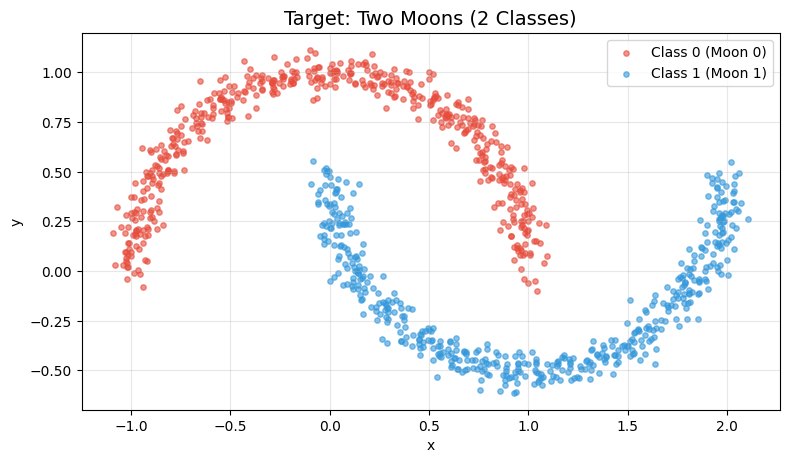

In [ ]:
# Visualize target with class colors
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E74C3C', '#3498DB']  # Red for class 0, Blue for class 1

for c in [0, 1]:
    mask = labels_moons == c
    ax.scatter(
        data_moons[mask, 0].cpu(), data_moons[mask, 1].cpu(),
        c=colors[c], alpha=0.6, s=15, label=f'Class {c} (Moon {c})'
    )

ax.set_title('Target: Two Moons (2 Classes)', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Create Initial Distribution: 8 Gaussians

- We have 8 Gaussians, whose means are placed on a circle with idential var.
- We generate 8 samples from each Gaussian -> Resulting distribution would be a mixture of Gaussians.
    - Instead of randomly sampling k (Gaussian dist k) for each point, the code explicitly generates equal numbers per cluster, which results in the same uniform mixture distribution.
        - Since finite sample, we would get unbalanced samples otherwise.

In [ ]:
# 8 Gaussians as structured initial noise
n_samples_init = 64
n_classes_init = 8

data_8gauss, labels_8gauss = make_gaussian_mixture(
    n_samples_per_class=n_samples_init // n_classes_init,
    n_classes=n_classes_init,
    spread=1.0,
    std=0.15
)
data_8gauss = data_8gauss.to(device)

print(f"Initial samples: {data_8gauss.shape[0]}")

Initial samples: 64


## 3. Setup Conditional Denoiser and Noise Schedule

In [ ]:
# Create Conditional Exact Denoiser
denoiser = ConditionalExactDenoiser(data_moons, labels_moons)

print(f"Conditional denoiser created")
print(f"  - Number of classes: {denoiser.n_classes}")
print(f"  - Data points: {denoiser.n_points}")

Conditional denoiser created
  - Number of classes: 2
  - Data points: 1000


In [ ]:
# Karras noise schedule
n_steps = 50
sigma_min = 0.01
sigma_max = 5.0

sigmas = get_sigmas_karras(
    n_steps=n_steps,
    sigma_min=sigma_min,
    sigma_max=sigma_max,
    device=device
)

# Scale initial samples
latents = data_8gauss * sigmas[0]

print(f"Noise schedule: {n_steps} steps, sigma=[{sigma_min}, {sigma_max}]")

Noise schedule: 50 steps, sigma=[0.01, 5.0]


## 4. Conditional Generation: Generate Class 0 vs Class 1

Compare generating samples conditioned on Class 0 (upper moon) vs Class 1 (lower moon).

In [7]:
# Generate Class 0 (upper moon)
condition_0 = torch.zeros(latents.shape[0], dtype=torch.long, device=device)
traj_class0 = sample_heun(
    denoiser=denoiser,
    latents=latents.clone(),
    sigmas=sigmas,
    condition=condition_0,
    guidance_scale=1.0,  # Pure conditional (no CFG boost)
    return_trajectory=True
)

# Generate Class 1 (lower moon)
condition_1 = torch.ones(latents.shape[0], dtype=torch.long, device=device)
traj_class1 = sample_heun(
    denoiser=denoiser,
    latents=latents.clone(),
    sigmas=sigmas,
    condition=condition_1,
    guidance_scale=1.0,
    return_trajectory=True
)

print(f"Generated trajectories: {traj_class0.shape}")

Generated trajectories: torch.Size([64, 51, 2])


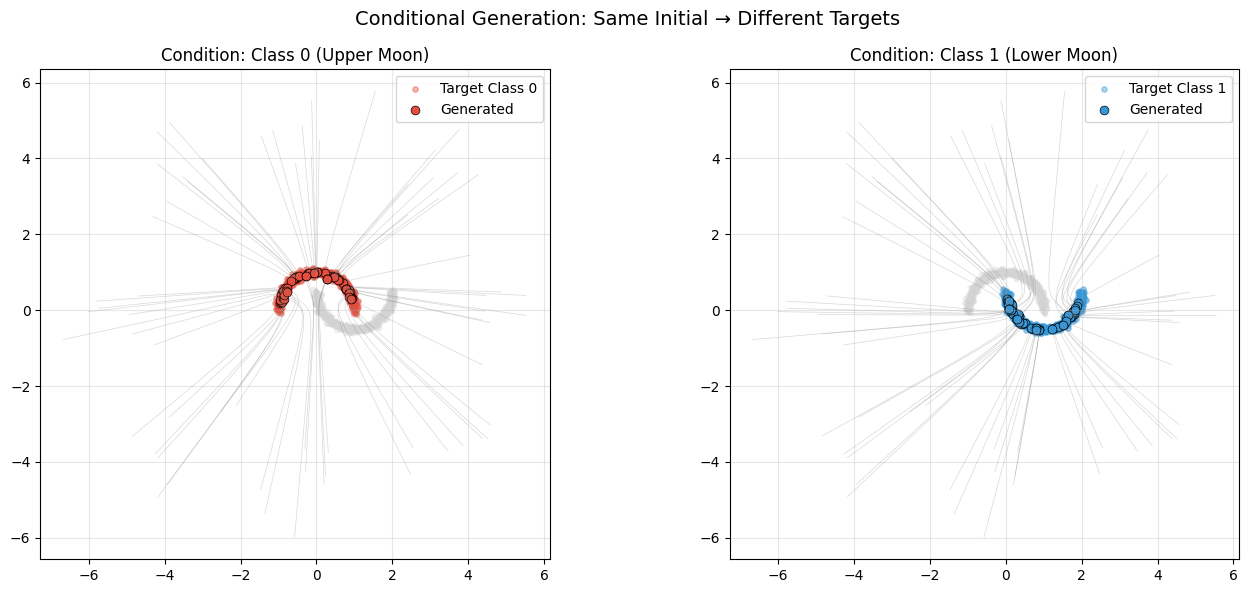

In [8]:
# Visualize: Class 0 vs Class 1 generation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

target_np = data_moons.cpu().numpy()
labels_np = labels_moons.cpu().numpy()

for idx, (traj, target_class, title) in enumerate([
    (traj_class0, 0, 'Condition: Class 0 (Upper Moon)'),
    (traj_class1, 1, 'Condition: Class 1 (Lower Moon)')
]):
    ax = axes[idx]
    traj_np = traj.cpu().numpy()
    
    # Plot target data (both classes in gray)
    ax.scatter(target_np[:, 0], target_np[:, 1], c='lightgray', alpha=0.3, s=10)
    
    # Highlight target class
    mask = labels_np == target_class
    ax.scatter(
        target_np[mask, 0], target_np[mask, 1],
        c=colors[target_class], alpha=0.4, s=15, label=f'Target Class {target_class}'
    )
    
    # Plot trajectories
    for i in range(traj_np.shape[0]):
        ax.plot(traj_np[i, :, 0], traj_np[i, :, 1], '-', color='gray', alpha=0.3, linewidth=0.5)
    
    # Plot final samples
    ax.scatter(
        traj_np[:, -1, 0], traj_np[:, -1, 1],
        c=colors[target_class], s=40, edgecolors='black', linewidth=0.5,
        label='Generated'
    )
    
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Conditional Generation: Same Initial → Different Targets', fontsize=14)
plt.tight_layout()
plt.show()

## 5. CFG Scale Comparison

Compare different CFG scales: 1.0 (pure conditional), 3.0, 5.0, 7.0

Higher CFG scale = stronger guidance toward the target class, but may overshoot.

In [ ]:
# Generate with different CFG scales for Class 0
cfg_scales = [1.0, 3.0, 5.0, 7.0]
target_class = 0  # Focus on upper moon

condition = torch.full((latents.shape[0],), target_class, dtype=torch.long, device=device)

trajectories_cfg = {}
for cfg_scale in cfg_scales:
    traj = sample_heun(
        denoiser=denoiser,
        latents=latents.clone(),
        sigmas=sigmas,
        condition=condition,
        guidance_scale=cfg_scale,
        return_trajectory=True
    )
    trajectories_cfg[cfg_scale] = traj
    print(f"CFG scale {cfg_scale}: done")

CFG scale 1.0: done
CFG scale 3.0: done
CFG scale 5.0: done
CFG scale 7.0: done


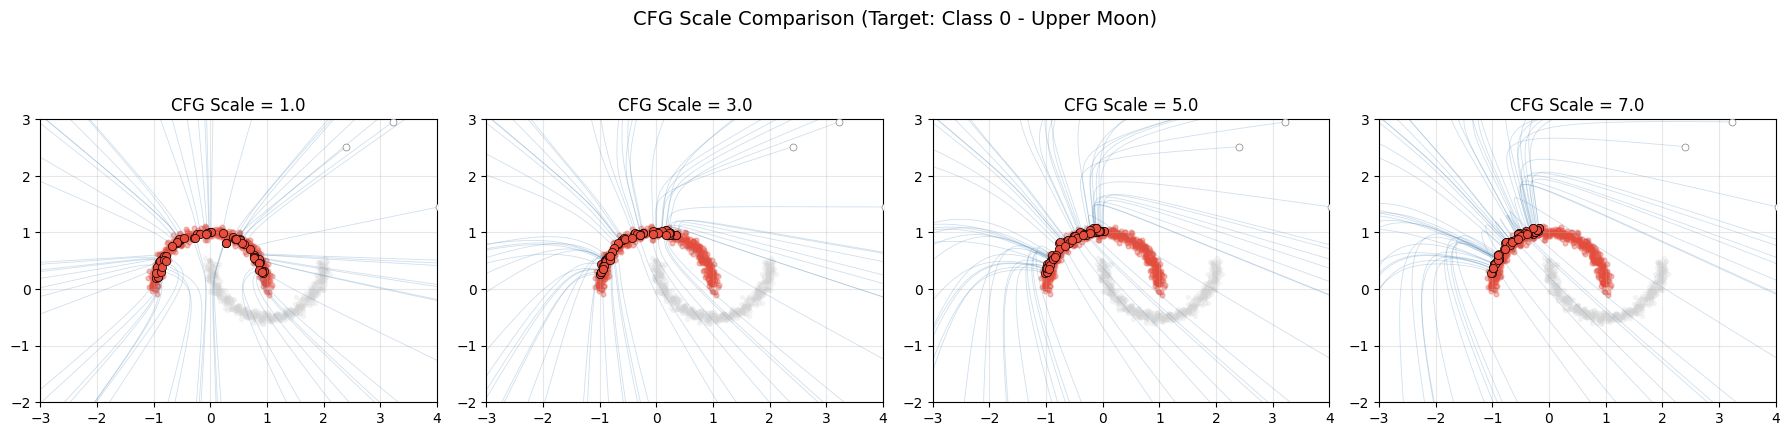

In [ ]:
# Visualize CFG scale comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

target_np = data_moons.cpu().numpy()
labels_np = labels_moons.cpu().numpy()

for idx, cfg_scale in enumerate(cfg_scales):
    ax = axes[idx]
    traj_np = trajectories_cfg[cfg_scale].cpu().numpy()
    
    # Plot all target data in light gray
    ax.scatter(target_np[:, 0], target_np[:, 1], c='lightgray', alpha=0.2, s=8)
    
    # Highlight target class
    mask = labels_np == target_class
    ax.scatter(
        target_np[mask, 0], target_np[mask, 1],
        c=colors[target_class], alpha=0.3, s=12
    )
    
    # Plot trajectories
    for i in range(traj_np.shape[0]):
        ax.plot(traj_np[i, :, 0], traj_np[i, :, 1], '-', color='steelblue', alpha=0.25, linewidth=0.6)
    
    # Plot start points
    ax.scatter(
        traj_np[:, 0, 0], traj_np[:, 0, 1],
        c='white', s=25, edgecolors='gray', linewidth=0.5, zorder=5
    )
    
    # Plot final samples
    ax.scatter(
        traj_np[:, -1, 0], traj_np[:, -1, 1],
        c=colors[target_class], s=35, edgecolors='black', linewidth=0.5, zorder=6
    )
    
    ax.set_title(f'CFG Scale = {cfg_scale}', fontsize=12)
    ax.set_xlim(-3, 4)
    ax.set_ylim(-2, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'CFG Scale Comparison (Target: Class {target_class} - Upper Moon)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Quantitative Analysis: Distance to Target Class

In [11]:
def compute_distance_to_class(samples, data, labels, target_class):
    """Compute average distance from samples to nearest point in target class."""
    mask = labels == target_class
    class_data = data[mask]
    
    # Compute pairwise distances: [n_samples, n_class_points]
    diff = samples.unsqueeze(1) - class_data.unsqueeze(0)
    dists = (diff ** 2).sum(dim=-1).sqrt()  # [n_samples, n_class_points]
    
    # Minimum distance to any point in target class
    min_dists = dists.min(dim=1).values
    return min_dists.mean().item(), min_dists.std().item()


# Analyze final samples for each CFG scale
print(f"Distance to Target Class {target_class} (Upper Moon):")
print("-" * 50)

results = []
for cfg_scale in cfg_scales:
    final_samples = trajectories_cfg[cfg_scale][:, -1, :]
    mean_dist, std_dist = compute_distance_to_class(
        final_samples, data_moons, labels_moons, target_class
    )
    results.append((cfg_scale, mean_dist, std_dist))
    print(f"  CFG {cfg_scale:>4}: mean={mean_dist:.4f}, std={std_dist:.4f}")

# Also compute distance to wrong class
print(f"\nDistance to Wrong Class {1-target_class} (Lower Moon):")
print("-" * 50)

for cfg_scale in cfg_scales:
    final_samples = trajectories_cfg[cfg_scale][:, -1, :]
    mean_dist, std_dist = compute_distance_to_class(
        final_samples, data_moons, labels_moons, 1 - target_class
    )
    print(f"  CFG {cfg_scale:>4}: mean={mean_dist:.4f}, std={std_dist:.4f}")

Distance to Target Class 0 (Upper Moon):
--------------------------------------------------
  CFG  1.0: mean=0.0046, std=0.0043
  CFG  3.0: mean=0.0051, std=0.0038
  CFG  5.0: mean=0.0044, std=0.0036
  CFG  7.0: mean=0.0034, std=0.0039

Distance to Wrong Class 1 (Lower Moon):
--------------------------------------------------
  CFG  1.0: mean=0.6328, std=0.1403
  CFG  3.0: mean=0.6353, std=0.1562
  CFG  5.0: mean=0.6477, std=0.1615
  CFG  7.0: mean=0.6803, std=0.1494


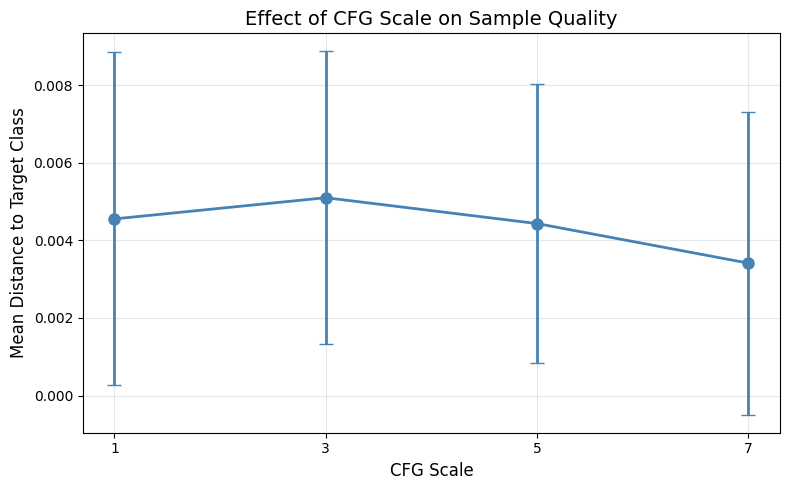

In [12]:
# Plot distance metrics
fig, ax = plt.subplots(figsize=(8, 5))

cfg_vals = [r[0] for r in results]
mean_vals = [r[1] for r in results]
std_vals = [r[2] for r in results]

ax.errorbar(cfg_vals, mean_vals, yerr=std_vals, fmt='o-', capsize=5, 
            markersize=8, linewidth=2, color='steelblue')
ax.set_xlabel('CFG Scale', fontsize=12)
ax.set_ylabel('Mean Distance to Target Class', fontsize=12)
ax.set_title('Effect of CFG Scale on Sample Quality', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xticks(cfg_vals)

plt.tight_layout()
plt.show()

## 7. Conditional Vector Field Visualization

Compare the denoising vector field for different conditions.

In [ ]:
def plot_conditional_vector_field(
    denoiser,
    sigma: float,
    condition: int,
    target_data: torch.Tensor,
    target_labels: torch.Tensor,
    guidance_scale: float = 1.0,
    xlim=(-2, 3),
    ylim=(-1.5, 2),
    grid_size=18,
    ax=None
):
    """Plot conditional denoising vector field."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    device = target_data.device
    
    # Create grid
    x = torch.linspace(xlim[0], xlim[1], grid_size, device=device)
    y = torch.linspace(ylim[0], ylim[1], grid_size, device=device)
    xx, yy = torch.meshgrid(x, y, indexing='xy')
    grid_points = torch.stack([xx.flatten(), yy.flatten()], dim=1)
    
    # Get denoised predictions
    sigma_tensor = torch.full((grid_points.shape[0],), sigma, device=device)
    cond_tensor = torch.full((grid_points.shape[0],), condition, dtype=torch.long, device=device)
    
    denoised = denoiser(
        grid_points, sigma_tensor,
        condition=cond_tensor,
        guidance_scale=guidance_scale
    )
    
    displacement = denoised - grid_points
    
    # Plot target data
    target_np = target_data.cpu().numpy()
    labels_np = target_labels.cpu().numpy()
    
    # Other class in light gray
    mask_other = labels_np != condition
    ax.scatter(target_np[mask_other, 0], target_np[mask_other, 1], 
               c='lightgray', alpha=0.3, s=8)
    
    # Target class highlighted
    mask_target = labels_np == condition
    ax.scatter(target_np[mask_target, 0], target_np[mask_target, 1],
               c=colors[condition], alpha=0.5, s=12)
    
    # Vector field
    grid_np = grid_points.cpu().numpy()
    disp_np = displacement.cpu().numpy()
    
    ax.quiver(
        grid_np[:, 0], grid_np[:, 1],
        disp_np[:, 0], disp_np[:, 1],
        alpha=0.7, color='darkblue', scale=20
    )
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    return ax

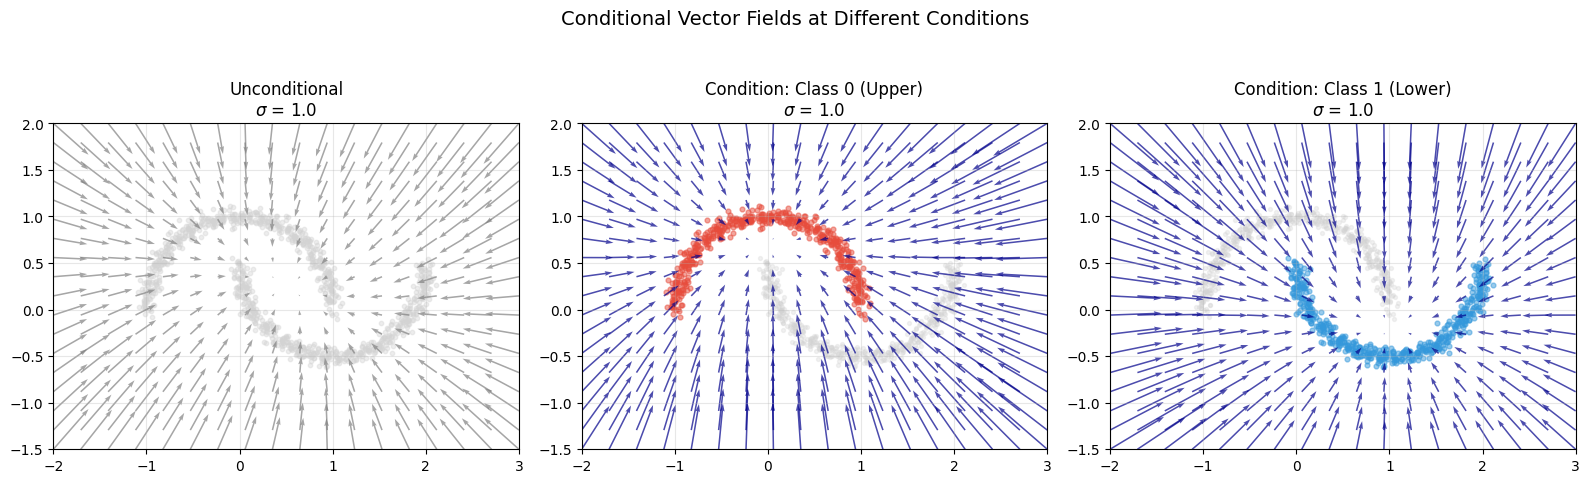

In [14]:
# Compare vector fields: Unconditional vs Class 0 vs Class 1
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sigma_vis = 1.0

# Unconditional
ax = axes[0]
x = torch.linspace(-2, 3, 18, device=device)
y = torch.linspace(-1.5, 2, 18, device=device)
xx, yy = torch.meshgrid(x, y, indexing='xy')
grid_points = torch.stack([xx.flatten(), yy.flatten()], dim=1)
sigma_tensor = torch.full((grid_points.shape[0],), sigma_vis, device=device)

denoised_uncond = denoiser(grid_points, sigma_tensor, condition=None)
disp_uncond = (denoised_uncond - grid_points).cpu().numpy()
grid_np = grid_points.cpu().numpy()
target_np = data_moons.cpu().numpy()

ax.scatter(target_np[:, 0], target_np[:, 1], c='lightgray', alpha=0.4, s=10)
ax.quiver(grid_np[:, 0], grid_np[:, 1], disp_uncond[:, 0], disp_uncond[:, 1],
          alpha=0.7, color='gray', scale=20)
ax.set_title(f'Unconditional\n$\\sigma$ = {sigma_vis}', fontsize=12)
ax.set_xlim(-2, 3)
ax.set_ylim(-1.5, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Class 0
plot_conditional_vector_field(
    denoiser, sigma_vis, condition=0,
    target_data=data_moons, target_labels=labels_moons,
    ax=axes[1]
)
axes[1].set_title(f'Condition: Class 0 (Upper)\n$\\sigma$ = {sigma_vis}', fontsize=12)

# Class 1
plot_conditional_vector_field(
    denoiser, sigma_vis, condition=1,
    target_data=data_moons, target_labels=labels_moons,
    ax=axes[2]
)
axes[2].set_title(f'Condition: Class 1 (Lower)\n$\\sigma$ = {sigma_vis}', fontsize=12)

fig.suptitle('Conditional Vector Fields at Different Conditions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. CFG Effect on Vector Field

See how CFG scale amplifies the conditional direction.

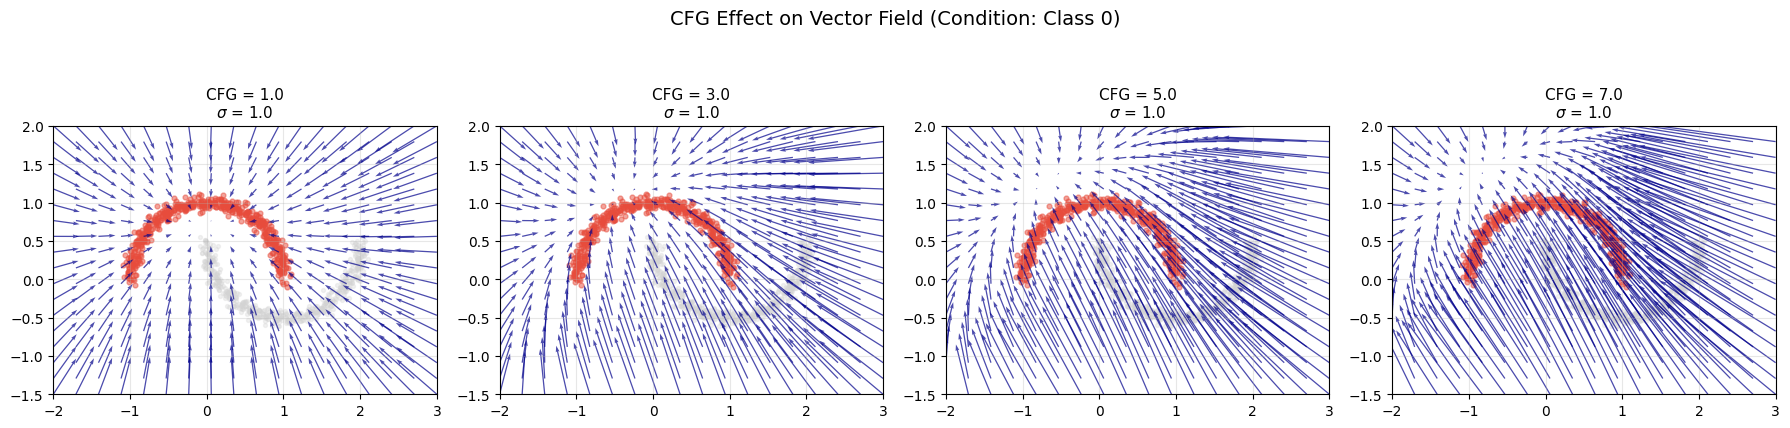

In [ ]:
# CFG effect on vector field
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
sigma_vis = 1.0
target_class = 0

for idx, cfg_scale in enumerate(cfg_scales):
    plot_conditional_vector_field(
        denoiser, sigma_vis, condition=target_class,
        target_data=data_moons, target_labels=labels_moons,
        guidance_scale=cfg_scale,
        ax=axes[idx]
    )
    axes[idx].set_title(f'CFG = {cfg_scale}\n$\\sigma$ = {sigma_vis}', fontsize=11)

fig.suptitle(f'CFG Effect on Vector Field (Condition: Class {target_class})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Summary

**Key Observations:**

1. **Conditional Generation**: Same initial samples can be guided to different target classes
2. **CFG Scale Effect**:
   - CFG = 1.0: Pure conditional (vectors point to class centroid)
   - CFG > 1.0: Amplified guidance (vectors exaggerate class direction)
   - Higher CFG = tighter clustering on target, but may overshoot
3. **Vector Field**: Clearly shows how conditioning changes the denoising direction

In [ ]:
print("Conditional generation demo complete!")
print(f"  - Target: Two Moons (2 classes)")
print(f"  - Initial: 8 Gaussians ({n_samples_init} samples)")
print(f"  - CFG scales tested: {cfg_scales}")

Conditional generation demo complete!
  - Target: Two Moons (2 classes)
  - Initial: 8 Gaussians (64 samples)
  - CFG scales tested: [1.0, 3.0, 5.0, 7.0]
